<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Deep Reinforcement Learning: DQN y Gradientes de Política con Redes 🤖
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Machine Learning
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 06
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Machine%20Learning/06%20-%20Aprendizaje%20por%20Refuerzo/03_Deep_RL_DQN_y_Policy_Gradient.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## Objetivos de Aprendizaje 🔎

Este cuaderno cierra el módulo con la **Sección 2.9 (*Deep Reinforcement Learning: DQN, Policy Gradient Methods*)** del Capítulo 2. Los cuadernos [01](01_Funciones_de_Valor_y_Q_Learning.ipynb) y [02](02_Gradientes_de_Politica.ipynb) resolvieron MDP **pequeños** con tablas. Aquí aparece el problema real: espacios de estados **enormes o continuos**, donde la tabla no cabe y hay que **aproximar** $Q$ o $\pi$ con **redes neuronales**. Es también donde el RL se vuelve **frágil**: lo mostraremos con **honestidad**, con varias semillas y sin esconder las malas.

Al terminar podrás:

1. **Cuantificar** por qué el enfoque tabular no escala (explosión de estados) y qué cambia al **aproximar funciones**.
2. **Explicar y demostrar** la **«tríada letal»** (aproximación + *bootstrapping* + *off-policy*) con el **contraejemplo de Baird**, implementado desde cero.
3. **Describir** el algoritmo **DQN** (Mnih et al., 2015): red $Q$, **memoria de repetición**, **red objetivo**, $\varepsilon$-*greedy* con decaimiento y **pérdida de Huber**, y por qué cada pieza estabiliza el entrenamiento.
4. **Implementar** DQN en **PyTorch** sobre `CartPole-v1` y **REINFORCE** (con y sin *baseline*), con presupuesto reproducible, y **verificar** piezas con *asserts* (dimensiones, sincronización de la red objetivo, objetivo TD, gradiente).
5. **Evaluar con rigor**: curvas de aprendizaje con **varias semillas** (media ± desviación **y** curvas individuales), y reconocer **inestabilidad** y **sensibilidad a hiperparámetros**.
6. **Situar** *Double DQN*, A2C y PPO como el siguiente paso (sin implementarlos).

> 📍 **Dónde estamos:** Módulo 06, cuaderno 4 de 4 (después de [Gradientes de política](02_Gradientes_de_Politica.ipynb)). El módulo siguiente cierra el Capítulo 2 con la **selección de modelos** (Módulo 07).

> 🔗 **Para no repetir:** las redes neuronales y PyTorch (`nn.Module`, `autograd`, optimizadores) se desarrollaron en el [Módulo 02, cuaderno 02](../02%20-%20Arboles%20Bosques%20y%20Redes%20Neuronales/02_Redes_Neuronales.ipynb); aquí se **usan**, no se explican. La API de Gymnasium y la diferencia `terminated`/`truncated` están en el [cuaderno 00](00_Fundamentos_RL_y_MDPs.ipynb); el teorema del gradiente de la política y las *baselines* en el [cuaderno 02](02_Gradientes_de_Politica.ipynb).

> ⏱️ **Presupuesto de cómputo.** La bandera `RAPIDO = True` (por defecto) entrena con un presupuesto **reducido** (~1–1.5 minutos en CPU en total). Con `RAPIDO = False` se usan 5 semillas y más pasos (**≈ 10 minutos** en CPU) y las curvas son más fiables; ahí se activa además un barrido de hiperparámetros de DQN.

---
## Recursos Recomendados 📚

### 📖 Libros de Referencia:
- *Hands-On Machine Learning with Scikit-Learn and PyTorch* — **Aurélien Géron** (O'Reilly, 2025). Cap. 19 (*Reinforcement Learning*): *Policy Gradients* (*Solving the CartPole Using Policy Gradients*), *Approximate Q-Learning and Deep Q-Learning*, *Implementing Deep Q-Learning*, *DQN Improvements* (modelo objetivo, *double DQN*, *prioritized experience replay*, *dueling DQN*), *Actor-Critic Algorithms* y *Overview of Some Popular RL Algorithms* (disponible en `Machine Learning/Libros/`; capítulo verificado contra el PDF). Advierte que el RL es **notoriamente difícil** y que REINFORCE es **inestable**.
- *Reinforcement Learning: An Introduction* — **Sutton & Barto** (MIT Press, 2.ª ed., 2018). Cap. 9–11 (aproximación de funciones; **tríada letal** y contraejemplo de Baird en el Cap. 11) y Cap. 13 *(citado de memoria, verificar)*.
- Mnih, V. et al. (2013), *Playing Atari with Deep Reinforcement Learning*, arXiv:1312.5602, y Mnih, V. et al. (2015), *Human-level control through deep reinforcement learning*, **Nature** 518: 529–533 (ambos citados en el capítulo de Géron; verificados).
- Williams, R. J. (1992), *Simple statistical gradient-following algorithms for connectionist reinforcement learning*, **Machine Learning** 8: 229–256 (REINFORCE; citado en Géron).
- van Hasselt, H., Guez, A. & Silver, D., *Deep reinforcement learning with double Q-learning*, **AAAI-30**, pp. 2094–2100 (citado en el capítulo de Géron, que lo fecha en 2015; el año de las actas es 2016); Schaul, T. et al. (2015), *Prioritized experience replay*, arXiv:1511.05952, y Wang, Z. et al. (2016), *Dueling network architectures for deep reinforcement learning* (ambos citados en Géron).
- Schulman, J. et al. (2017), *Proximal policy optimization algorithms*, arXiv:1707.06347 *(citado de memoria, verificar)*. Henderson, P. et al. (2018), *Deep reinforcement learning that matters*, **AAAI** *(citado de memoria, verificar)*: sobre la **reproducibilidad** y la sensibilidad a semillas.
- Irpan, A. (2018), *Deep Reinforcement Learning Doesn't Work Yet* (entrada de blog; la cita Géron en su capítulo como lectura sobre las dificultades y limitaciones del RL).

### 🌐 Documentación y Recursos Online:
- [Gymnasium: *CartPole*](https://gymnasium.farama.org/environments/classic_control/cart_pole/) · [PyTorch: *Reinforcement Learning (DQN) Tutorial*](https://pytorch.org/tutorials/intermediate/reinforcement_q_learning.html) *(citado de memoria, verificar)*
- [Stable-Baselines3](https://stable-baselines3.readthedocs.io/): implementaciones de referencia de DQN, A2C, PPO y SAC (no se usa en este cuaderno).

---
## 1. Cuando la Tabla No Cabe: Aproximación de Funciones y la Tríada Letal ☠️

### 1.1 La explosión de estados

Q-learning tabular guarda un valor por cada par $(s,a)$. En *FrozenLake* son 64 números; en problemas reales, la tabla es **imposible**:

- Una **discretización** de las 4 variables continuas de *CartPole* con $b$ intervalos cada una ya da $b^4$ estados: 10⁴ con $b=10$, 10⁸ con $b=100$, y se pierde precisión en las fronteras.
- Una imagen de Atari ($210\times160$ píxeles RGB de 8 bits) tiene $256^{100800}\approx10^{242\,700}$ imágenes posibles; el Go tiene del orden de $10^{170}$ posiciones legales *(citado de memoria, verificar)*.

Pero hay un segundo problema, aún más importante: **generalización**. Una tabla trata cada estado como **independiente**: lo aprendido en un estado no ayuda en uno **parecido**. La solución es **aproximar** $q(s,a)\approx Q_\theta(s,a)$ con una función paramétrica (una **red neuronal**), que comparte parámetros entre estados y **generaliza** a estados nunca vistos. Es el mismo paso que en el aprendizaje supervisado: de memorizar a **aprender una función**.

### 1.2 La «tríada letal» (Sutton & Barto, Cap. 11)

El *bootstrapping* (el objetivo usa la propia estimación), la aproximación de funciones y el aprendizaje ***off-policy*** son cada uno deseables; **juntos pueden hacer divergir** el aprendizaje, aun en problemas triviales:

| Ingrediente | Por qué lo queremos |
|---|---|
| **Aproximación de funciones** | Escalar y generalizar a estados no vistos |
| ***Bootstrapping*** (TD) | Aprender paso a paso, con baja varianza |
| ***Off-policy*** | Reutilizar datos (memoria de repetición), aprender la política óptima mientras se explora |

Q-learning con una red cumple **las tres**; **DQN** es en esencia un conjunto de **parches prácticos** (memoria de repetición, red objetivo) para domar esa combinación, **sin garantías teóricas**. Lo demostramos con el **contraejemplo de Baird** (7 estados, 8 pesos, valor verdadero $0$ representable exactamente) donde la actualización TD semigradiente **off-policy** con aproximación lineal **diverge**.

In [ ]:
# ============================================================
# Configuracion inicial
# ============================================================
# !pip install -q gymnasium torch
# (numpy, pandas, matplotlib y seaborn vienen preinstalados en Google Colab; torch tambien. gymnasium se instala con la linea de arriba si hiciera falta)

import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
PALETA = ["#2563eb", "#dc2626", "#16a34a", "#f59e0b", "#7c3aed", "#0891b2", "#db2777", "#65a30d", "#78350f", "#475569"]
torch.set_num_threads(1)                                  # redes pequenas: 1 hilo es mas rapido y mas reproducible
DEVICE = "cpu"                                            # CartPole + MLP pequenos: la GPU no ayuda
print(f"NumPy {np.__version__} | Gymnasium {gym.__version__} | PyTorch {torch.__version__} | dispositivo: {DEVICE}")

# ------------------------------------------------------------
# PRESUPUESTO DE COMPUTO (ver la nota al inicio del cuaderno)
# ------------------------------------------------------------
RAPIDO = True            # True: ~1-1.5 min en CPU | False: ~10 min, mas semillas y mas pasos (curvas mas fiables)
if RAPIDO:
    SEMILLAS, PASOS_DQN, ITER_PG = [0, 1, 2], 10_000, 50
else:
    SEMILLAS, PASOS_DQN, ITER_PG = [0, 1, 2, 3, 4], 30_000, 100
print(f"RAPIDO = {RAPIDO}: semillas = {SEMILLAS}, pasos de DQN = {PASOS_DQN:,}, iteraciones de REINFORCE = {ITER_PG}")

In [ ]:
# ============================================================
# 1.1 La explosion de estados, en numeros
# ============================================================
log10_atari = 210 * 160 * 3 * np.log10(256)
print(f"Imagenes de Atari posibles: 256^(210*160*3) ~ 10^{log10_atari:,.0f}")
bins = np.array([2, 5, 10, 20, 50, 100])
print("CartPole discretizado con b intervalos por variable:", {int(b): f"{b ** 4:,}" for b in bins}, "estados")
assert np.isclose(log10_atari, 100800 * np.log10(256)) and 242000 < log10_atari < 243000

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.semilogy(bins, bins.astype(float) ** 4, "o-", color=PALETA[0], lw=2.5, label=r"CartPole discretizado: $b^4$ estados")
ax.axhline(64, color=PALETA[2], ls="--", label="FrozenLake 8x8 (64 estados)")
ax.axhline(1e9, color=PALETA[1], ls=":", label="~1e9: límite razonable para una tabla en memoria")
ax.set_xlabel("Intervalos por variable $b$"); ax.set_ylabel("Número de estados (escala log)")
ax.set_title("Discretizar el espacio continuo hace explotar la tabla (y pierde precisión)", fontweight="bold"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# 1.2 La triada letal: contraejemplo de Baird (Sutton & Barto, Cap. 11), DESDE CERO
# ============================================================
# 7 estados. Accion "punteada": salta a uno de los estados 0..5 al azar; accion "solida": salta al estado 6.
# Politica de COMPORTAMIENTO: punteada con prob. 6/7, solida con 1/7. Politica OBJETIVO: siempre "solida".  Recompensa 0 siempre, gamma = 0.99.
# => el valor verdadero es 0 en todos los estados, y es REPRESENTABLE exactamente con w = 0 (8 pesos).
# Caracteristicas lineales: x(s_i) = 2 e_i + e_7 (i = 0..5);  x(s_6) = e_6 + 2 e_7.
X_LIN = np.zeros((7, 8))
for i in range(6):
    X_LIN[i, i], X_LIN[i, 7] = 2.0, 1.0
X_LIN[6, 6], X_LIN[6, 7] = 1.0, 2.0
X_TAB = np.eye(7)                                          # caracteristicas "tabulares" (sin aproximacion)

def baird(X, w0, pasos=3000, alpha=0.01, gamma=0.99, semilla=0):
    """TD(0) semigradiente OFF-POLICY con razon de importancia rho = pi(a|s)/b(a|s).  Devuelve la trayectoria de pesos."""
    rng = np.random.default_rng(semilla)
    w = w0.astype(float).copy(); s = int(rng.integers(7)); hist = [w.copy()]
    for _ in range(pasos):
        if rng.random() < 6 / 7:
            s2, rho = int(rng.integers(6)), 0.0            # punteada: la politica objetivo NUNCA la elige -> rho = 0 / (6/7) = 0
        else:
            s2, rho = 6, 7.0                               # solida: rho = 1 / (1/7) = 7
        delta = gamma * X[s2] @ w - X[s] @ w               # error TD (recompensa 0)
        w += alpha * rho * delta * X[s]                    # actualizacion semigradiente ponderada por rho
        s = s2; hist.append(w.copy())
    return np.array(hist)

w0_lin = np.array([1, 1, 1, 1, 1, 1, 10, 1.0]); w0_tab = np.array([1, 1, 1, 1, 1, 1, 10.0])
H_lin = [baird(X_LIN, w0_lin, semilla=k) for k in range(3)]
H_tab = [baird(X_TAB, w0_tab, semilla=k) for k in range(3)]
norma_lin = [np.abs(H @ X_LIN.T).max(axis=1) for H in H_lin]           # max_s |v(s)| con aproximacion lineal
norma_tab = [np.abs(H).max(axis=1) for H in H_tab]                     # max_s |v(s)| tabular
print("max|v(s)| inicial: lineal =", np.round(norma_lin[0][0], 1), "| tabular =", np.round(norma_tab[0][0], 1), "(el valor verdadero es 0)")
for k in range(3):
    print(f"  semilla {k}: tras 3000 pasos, max|v| lineal = {norma_lin[k][-1]:.3g} (DIVERGE) | tabular = {norma_tab[k][-1]:.3g} (baja, lentamente)")
assert all(n[-1] > 1e3 * n[0] for n in norma_lin)                      # con aproximacion lineal, off-policy y bootstrapping: diverge
assert all(n[-1] <= n[0] + 1e-9 for n in norma_tab)                     # sin aproximacion (tabular) NO diverge

fig, ax = plt.subplots(figsize=(9.5, 4.8))
for k in range(3):
    ax.semilogy(norma_lin[k], color=PALETA[1], lw=2, alpha=0.9, label="Lineal (aproximación + bootstrapping + off-policy)" if k == 0 else None)
    ax.semilogy(norma_tab[k], color=PALETA[2], lw=2, alpha=0.9, label="Tabular (sin aproximación)" if k == 0 else None)
ax.set_xlabel("Pasos"); ax.set_ylabel(r"$\max_s|\hat v(s)|$ (el valor verdadero es 0), escala log")
ax.set_title("Contraejemplo de Baird: con la tríada letal, el valor estimado DIVERGE", fontweight="bold"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print("Lectura: el valor verdadero (0) es representable EXACTAMENTE con w = 0, y aun asi el aprendizaje se aleja. Quitar cualquiera de los tres ingredientes lo evita.")

---
##### 🛠️ Práctica 1: Quitar un ingrediente de la tríada letal: Baird *on-policy*

El contraejemplo de Baird diverge porque combina **aproximación lineal**, ***bootstrapping*** y aprendizaje ***off-policy***. Elimina el último ingrediente. Con `X_LIN`, `w0_lin` y `norma_lin` del §1.2:

1. Escribe `baird_on_policy(X, w0, pasos=3000, alpha=0.01, gamma=0.99, semilla=0)`: igual que `baird`, pero ahora el agente **se comporta con la política objetivo**: siempre salta al estado 6 (`s2 = 6`) y la razón de importancia es `rho = 1.0`.
2. Ejecútala con `X_LIN` y `w0_lin` y guarda en `norma_on` la serie $\max_s\lvert\hat v(s)\rvert$ (`np.abs(H @ X_LIN.T).max(axis=1)`, donde `H` es la trayectoria de pesos).
3. Verifica con `assert` que **no diverge**: `norma_on[-1] < norma_on[0]` y `norma_on[-1] < 100`, mientras que la versión *off-policy* sí lo hacía (`norma_lin[0][-1] > 1e3`).

In [ ]:
# Escribe tu código aquí

# def baird_on_policy(X, w0, pasos=3000, alpha=0.01, gamma=0.99, semilla=0):
#     rng = np.random.default_rng(semilla)
#     w = w0.astype(float).copy(); s = int(rng.integers(7)); hist = [w.copy()]
#     for _ in range(pasos):
#         s2, rho = 6, 1.0                               # el agente sigue la politica objetivo
#         delta = ...                                     # error TD (recompensa 0), como en baird
#         w += ...
#         s = s2; hist.append(w.copy())
#     return np.array(hist)
#
# H_on = baird_on_policy(X_LIN, w0_lin)
# norma_on = np.abs(H_on @ X_LIN.T).max(axis=1)


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
def baird_on_policy(X, w0, pasos=3000, alpha=0.01, gamma=0.99, semilla=0):
    # TD(0) semigradiente ON-POLICY: el agente se comporta con la politica objetivo (siempre al estado 6, rho = 1)
    rng = np.random.default_rng(semilla)
    w = w0.astype(float).copy(); s = int(rng.integers(7)); hist = [w.copy()]
    for _ in range(pasos):
        s2, rho = 6, 1.0                                   # comportamiento == objetivo: no hace falta corregir (rho = 1)
        delta = gamma * X[s2] @ w - X[s] @ w               # error TD (recompensa 0)
        w += alpha * rho * delta * X[s]
        s = s2; hist.append(w.copy())
    return np.array(hist)

H_on = baird_on_policy(X_LIN, w0_lin)
norma_on = np.abs(H_on @ X_LIN.T).max(axis=1)
print(f"max|v(s)|: inicial = {norma_on[0]:.1f} | final on-policy = {norma_on[-1]:.2f} | final off-policy (Baird) = {norma_lin[0][-1]:.3g}")
assert norma_on[-1] < norma_on[0]
assert norma_on[-1] < 100
assert norma_lin[0][-1] > 1e3
print("Sin el ingrediente off-policy (aun con aproximacion lineal y bootstrapping) el valor ya no diverge.")
```
</details>

---


---
## 2. DQN: *Deep Q-Network* 🧠

**Idea (Mnih et al., 2013, 2015).** Aproximar $q_{\ast}(s,a)$ con una red $Q_\theta(s)\in\mathbb R^{|\mathcal A|}$ (una salida por acción) y minimizar el **error TD** con descenso del gradiente. Con una muestra $(s,a,r,s',d)$ ($d=1$ si $s'$ es **terminal**):

$$y=r+\gamma\,(1-d)\,\max_{a'}Q_{\theta^-}(s',a'),\qquad \mathcal L(\theta)=\mathbb E_{(s,a,r,s',d)\sim\mathcal D}\Big[\ell_\delta\big(y-Q_\theta(s,a)\big)\Big].$$

Hacerlo ingenuamente **no funciona** (tríada letal). DQN añade cuatro piezas:

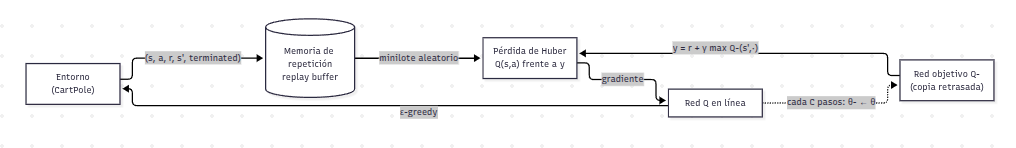

| Pieza | Problema que resuelve | Detalle |
|---|---|---|
| **Memoria de repetición** (*replay buffer*) | Los datos de un episodio están **muy correlacionados** (violan el supuesto i.i.d. del descenso del gradiente) y se usan una sola vez | Guarda las últimas $N$ transiciones y entrena con **minilotes aleatorios**: rompe la correlación y **reutiliza** datos (más eficiente en muestras). Hace al método *off-policy*. |
| **Red objetivo** $Q_{\theta^-}$ | El objetivo $y$ depende de $\theta$: se «persigue» a sí mismo (objetivo móvil) | Copia **congelada** de la red, sincronizada cada $C$ pasos ($\theta^-\leftarrow\theta$); $y$ cambia solo de vez en cuando |
| **$\varepsilon$-*greedy* con decaimiento** | Equilibrar exploración y explotación | $\varepsilon$ baja linealmente de 1 a un mínimo (aquí 0.05) |
| **Pérdida de Huber** | Errores TD enormes (al inicio o en transiciones raras) desestabilizan con el error cuadrático | $\ell_\delta(x)=\tfrac12x^2$ si $\lvert x\rvert\le\delta$; $\delta(\lvert x\rvert-\tfrac12\delta)$ si no (cuadrática cerca de 0, lineal lejos) + recorte de la norma del gradiente |

**Detalle crítico: `terminated` frente a `truncated`.** El factor $(1-d)$ usa **`terminated`** (el palo cayó): ahí el valor futuro es $0$. Si el episodio se **trunca** por tiempo (500 pasos) el estado **no es terminal** y se debe **bootstrappear** igualmente; poner $d=1$ en un truncamiento enseñaría un valor falso. Lo implementamos así.

**Mejoras conocidas (no implementadas):** *Double DQN* (separa la **selección** de la acción de su **evaluación** para reducir la sobreestimación: $y=r+\gamma Q_{\theta^-}(s',\arg\max_{a'}Q_\theta(s',a'))$), *Prioritized Experience Replay*, *Dueling DQN*, y combinaciones como *Rainbow*. Dejamos una bandera `doble` en nuestro código solo para el barrido opcional.

### El entorno: `CartPole-v1`

Un carro sobre un riel con un palo articulado. **Observación**: $(x,\dot x,\theta,\dot\theta)\in\mathbb R^4$. **Acciones**: empujar a la izquierda (0) o a la derecha (1). **Recompensa**: $+1$ por cada paso que el palo siga en pie. **Termina** si $|\theta|>12^\circ$ o $|x|>2.4$ (`terminated`), y se **trunca** a los 500 pasos (`truncated`): el máximo retorno es **500**. Una política aleatoria suele sumar ~20 puntos.

In [ ]:
# ============================================================
# 2. CartPole-v1: el entorno y la linea base aleatoria
# ============================================================
env = gym.make("CartPole-v1")
print("Observaciones:", env.observation_space, "| Acciones:", env.action_space, "| Limite de pasos:", env.spec.max_episode_steps)
obs, info = env.reset(seed=0)
assert obs.shape == (4,) and env.action_space.n == 2 and env.spec.max_episode_steps == 500

def episodio_aleatorio(env, semilla):
    obs, _ = env.reset(seed=semilla); G = 0.0
    while True:
        obs, r, terminated, truncated, _ = env.step(env.action_space.sample())      # 5 valores
        G += r
        if terminated or truncated:
            return G

env.action_space.seed(0)
retornos_aleatorios = np.array([episodio_aleatorio(env, 1000 + k) for k in range(200)])
RETORNO_ALEATORIO = retornos_aleatorios.mean()
print(f"Politica aleatoria (200 episodios): retorno medio = {RETORNO_ALEATORIO:.1f} ± {retornos_aleatorios.std():.1f} (min {retornos_aleatorios.min():.0f}, max {retornos_aleatorios.max():.0f}); maximo posible = 500")
assert 10 < RETORNO_ALEATORIO < 40
env.close()

In [ ]:
# ============================================================
# 2. DQN en PyTorch: red Q, memoria de repeticion, red objetivo, epsilon-greedy, Huber
# ============================================================
class RedQ(nn.Module):
    """Q_theta(s) -> vector de |A| valores (uno por accion). MLP pequeno: 4 -> 64 -> 64 -> 2."""
    def __init__(self, d_obs=4, n_acc=2, oculta=64):
        super().__init__()
        self.f = nn.Sequential(nn.Linear(d_obs, oculta), nn.ReLU(), nn.Linear(oculta, oculta), nn.ReLU(), nn.Linear(oculta, n_acc))
    def forward(self, x):
        return self.f(x)

class Memoria:
    """Memoria de repeticion CIRCULAR con arreglos NumPy preasignados: guarda (s, a, r, s', terminated)."""
    def __init__(self, capacidad, d_obs=4):
        self.cap, self.i, self.n = capacidad, 0, 0
        self.s, self.s2 = np.zeros((capacidad, d_obs), np.float32), np.zeros((capacidad, d_obs), np.float32)
        self.a, self.r, self.d = np.zeros(capacidad, np.int64), np.zeros(capacidad, np.float32), np.zeros(capacidad, np.float32)
    def agregar(self, s, a, r, s2, terminated):
        i = self.i
        self.s[i], self.a[i], self.r[i], self.s2[i], self.d[i] = s, a, r, s2, float(terminated)
        self.i, self.n = (i + 1) % self.cap, min(self.n + 1, self.cap)           # al llenarse, sobrescribe lo mas antiguo
    def muestrear(self, lote, rng):
        idx = rng.integers(0, self.n, lote)                                      # minilote ALEATORIO: rompe la correlacion temporal
        return tuple(torch.from_numpy(x[idx]) for x in (self.s, self.a, self.r, self.s2, self.d))

def objetivo_td(r, d, q_sig_max, gamma):
    """y = r + gamma * (1 - d) * max_a' Q_objetivo(s', a')   (d = terminated; en un estado terminal no hay futuro)."""
    return r + gamma * (1.0 - d) * q_sig_max

def evaluar_voraz(red, n_ep=5, semilla0=10_000):
    """Retorno medio de la politica VORAZ (sin exploracion) en n_ep episodios con semillas fijas."""
    env_e = gym.make("CartPole-v1"); tot = []
    for k in range(n_ep):
        obs, _ = env_e.reset(seed=semilla0 + k); G = 0.0
        while True:
            with torch.no_grad():
                a = int(red(torch.as_tensor(obs, dtype=torch.float32)).argmax())
            obs, r, terminated, truncated, _ = env_e.step(a); G += r
            if terminated or truncated:
                break
        tot.append(G)
    env_e.close()
    return float(np.mean(tot))

def entrenar_dqn(semilla, pasos, gamma=0.99, lr=1e-3, lote=32, capacidad=10_000, calentamiento=500, cada_entrenar=2,
                 sync=500, eps_fin=0.05, frac_eps=0.4, doble=False, cada_eval=1000, n_eval=5):
    """Entrena un DQN en CartPole-v1. Devuelve un dict con la red final y los registros (retornos de entrenamiento, evaluaciones voraces, perdidas)."""
    rng = np.random.default_rng(semilla); torch.manual_seed(semilla); random.seed(semilla)
    env = gym.make("CartPole-v1")
    q, q_obj = RedQ(), RedQ(); q_obj.load_state_dict(q.state_dict())
    opt = torch.optim.Adam(q.parameters(), lr=lr); mem = Memoria(capacidad)
    obs, _ = env.reset(seed=semilla); G = 0.0
    ret_ent, evals, perdidas = [], [], []
    eps_pasos = int(frac_eps * pasos); t0 = time.time()
    for t in range(1, pasos + 1):
        eps = max(eps_fin, 1.0 - (1.0 - eps_fin) * t / eps_pasos)                # decaimiento lineal de epsilon
        if rng.random() < eps:
            a = int(rng.integers(2))
        else:
            with torch.no_grad():
                a = int(q(torch.as_tensor(obs, dtype=torch.float32)).argmax())
        obs2, r, terminated, truncated, _ = env.step(a); G += r
        mem.agregar(obs, a, r, obs2, terminated)                                 # SOLO 'terminated' corta el bootstrapping
        obs = obs2
        if terminated or truncated:
            ret_ent.append((t, G)); G = 0.0; obs, _ = env.reset()
        if mem.n >= calentamiento and t % cada_entrenar == 0:
            s, aa, rr, s2, dd = mem.muestrear(lote, rng)
            with torch.no_grad():
                if doble:                                                         # Double DQN: la red en linea ELIGE la accion, la objetivo la EVALUA
                    q_sig = q_obj(s2).gather(1, q(s2).argmax(1, keepdim=True)).squeeze(1)
                else:
                    q_sig = q_obj(s2).max(1).values
                y = objetivo_td(rr, dd, q_sig, gamma)
            q_sa = q(s).gather(1, aa[:, None]).squeeze(1)                         # Q(s, a) de la accion que se tomo
            perdida = F.smooth_l1_loss(q_sa, y)                                  # Huber (delta = 1)
            opt.zero_grad(); perdida.backward()
            nn.utils.clip_grad_norm_(q.parameters(), 10.0)                        # recorte de la norma del gradiente
            opt.step(); perdidas.append(perdida.item())
        if t % sync == 0:
            q_obj.load_state_dict(q.state_dict())                                 # sincronizar la red objetivo cada 'sync' pasos
        if t % cada_eval == 0:
            evals.append((t, evaluar_voraz(q, n_eval)))
    env.close()
    return {"red": q, "ret_ent": ret_ent, "evals": evals, "perdidas": perdidas, "tiempo": time.time() - t0}

# ---------------- Comprobaciones de coherencia (pruebas minimas) ----------------
rng_t = np.random.default_rng(0)
m = Memoria(capacidad=5)
for k in range(7):
    m.agregar(np.full(4, k), k % 2, float(k), np.full(4, k + 1), k == 6)
assert m.n == 5 and m.i == 2 and set(m.r.tolist()) == {2.0, 3.0, 4.0, 5.0, 6.0}          # circular: conserva las 5 mas recientes
s, a, r, s2, d = m.muestrear(4, rng_t)
assert s.shape == (4, 4) and a.shape == (4,) and r.shape == (4,) and s2.shape == (4, 4) and d.shape == (4,) and s.dtype == torch.float32 and a.dtype == torch.int64
q1, q2 = RedQ(), RedQ()
assert any(not torch.equal(p1, p2) for p1, p2 in zip(q1.parameters(), q2.parameters()))   # redes distintas al inicio
q2.load_state_dict(q1.state_dict())
assert all(torch.equal(p1, p2) for p1, p2 in zip(q1.parameters(), q2.parameters()))       # tras sincronizar, la red objetivo == la red en linea
assert q1(torch.zeros(7, 4)).shape == (7, 2)                                              # una salida por accion
y = objetivo_td(torch.tensor([1.0, 1.0]), torch.tensor([1.0, 0.0]), torch.tensor([5.0, 5.0]), 0.9)
assert torch.allclose(y, torch.tensor([1.0, 5.5]))                                        # terminal: y = r | no terminal: y = r + gamma * max Q'
assert np.isclose(F.smooth_l1_loss(torch.tensor([0.5]), torch.tensor([0.0])).item(), 0.125)   # |x| <= 1: x^2/2
assert np.isclose(F.smooth_l1_loss(torch.tensor([10.0]), torch.tensor([0.0])).item(), 9.5)    # |x| > 1: |x| - 1/2 (el error cuadratico daria 50)
print("Comprobaciones OK: memoria circular, formas, sincronizacion de la red objetivo, objetivo TD (terminal vs no terminal) y perdida de Huber.")

---
##### 🛠️ Práctica 2: El objetivo de DQN: terminal, truncado y *Double DQN*

Con `RedQ`, `objetivo_td` y `torch`, calcula el objetivo $y$ de un minilote y compara variantes:

1. Fija `torch.manual_seed(1)`, crea `red_en_linea, red_obj = RedQ(), RedQ()` (dos redes distintas) y el minilote: `s2_lote = torch.randn(6, 4)`, `r_lote = torch.ones(6)`, `terminated_lote = torch.tensor([0., 0., 1., 0., 0., 1.])` y `truncated_lote = torch.tensor([0., 1., 0., 0., 0., 0.])`.
2. Dentro de `torch.no_grad()`, calcula `q_max = red_obj(s2_lote).max(1).values` y `y_dqn = objetivo_td(r_lote, terminated_lote, q_max, 0.99)`.
3. **Double DQN**: la red en línea *elige* la acción y la objetivo la *evalúa*, `q_doble = red_obj(s2_lote).gather(1, red_en_linea(s2_lote).argmax(1, keepdim=True)).squeeze(1)`; guarda `y_doble`.
4. **Error frecuente**: tratar `truncated` como terminal. Calcula `y_mal` usando `done_mal = torch.clamp(terminated_lote + truncated_lote, max=1)` en lugar de `terminated_lote`.
5. Verifica con `assert`: `y_doble <= y_dqn` (con tolerancia $10^{-6}$); en las muestras terminales `y_dqn == r_lote`; y `y_mal` **difiere** de `y_dqn` justo en la muestra truncada (índice 1) y en ninguna otra.

In [ ]:
# Escribe tu código aquí

# torch.manual_seed(1)
# red_en_linea, red_obj = RedQ(), RedQ()
# s2_lote = torch.randn(6, 4); r_lote = torch.ones(6)
# terminated_lote = torch.tensor([0., 0., 1., 0., 0., 1.])
# truncated_lote = torch.tensor([0., 1., 0., 0., 0., 0.])
# with torch.no_grad():
#     q_max = red_obj(s2_lote).max(1).values
#     y_dqn = objetivo_td(r_lote, terminated_lote, q_max, 0.99)
#     q_doble = ...
#     y_doble = ...
#     done_mal = torch.clamp(terminated_lote + truncated_lote, max=1)
#     y_mal = ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
torch.manual_seed(1)
red_en_linea, red_obj = RedQ(), RedQ()                     # dos redes distintas (inicializaciones aleatorias)
s2_lote = torch.randn(6, 4); r_lote = torch.ones(6)
terminated_lote = torch.tensor([0., 0., 1., 0., 0., 1.])   # muestras 2 y 5: el palo cayo (terminal)
truncated_lote = torch.tensor([0., 1., 0., 0., 0., 0.])    # muestra 1: corte por limite de tiempo (NO terminal)

with torch.no_grad():
    q_max = red_obj(s2_lote).max(1).values                                  # DQN: max de la red objetivo
    y_dqn = objetivo_td(r_lote, terminated_lote, q_max, 0.99)
    # Double DQN: la red en linea ELIGE la accion y la objetivo la EVALUA
    q_doble = red_obj(s2_lote).gather(1, red_en_linea(s2_lote).argmax(1, keepdim=True)).squeeze(1)
    y_doble = objetivo_td(r_lote, terminated_lote, q_doble, 0.99)
    # Error frecuente: tratar 'truncated' como terminal
    done_mal = torch.clamp(terminated_lote + truncated_lote, max=1)
    y_mal = objetivo_td(r_lote, done_mal, q_max, 0.99)

print("y (DQN)    :", y_dqn.numpy().round(3))
print("y (Double) :", y_doble.numpy().round(3))
print("y (mal)    :", y_mal.numpy().round(3))

assert (y_doble <= y_dqn + 1e-6).all()                                       # el max sobre-estima: evaluar la accion elegida nunca supera al max
assert torch.allclose(y_dqn[terminated_lote == 1], r_lote[terminated_lote == 1])   # terminal: y = r
dif = (y_mal - y_dqn).abs() > 1e-6
assert dif.tolist() == [False, True, False, False, False, False]             # el error aparece SOLO en la muestra truncada
print("Solo 'terminated' corta el bootstrapping: tratar 'truncated' como terminal falsea el objetivo de la muestra truncada.")
```
</details>

---


In [ ]:
# ============================================================
# 2. Entrenar DQN con varias semillas (¡todas se reportan!)
# ============================================================
t0 = time.time()
RES_DQN = {}
for k in SEMILLAS:
    RES_DQN[k] = entrenar_dqn(k, PASOS_DQN)
    r = RES_DQN[k]
    print(f"  semilla {k}: {r['tiempo']:.1f} s | episodios = {len(r['ret_ent'])} | evaluacion voraz final (20 ep.) = {evaluar_voraz(r['red'], 20):.1f}")
print(f"Tiempo total de DQN: {time.time() - t0:.1f} s")

In [ ]:
# ============================================================
# 2. Curvas de aprendizaje de DQN: curvas individuales + media ± desviacion
# ============================================================
def serie_por_ventana(ret_ent, pasos_total, ventana):
    """Retorno medio de los episodios que terminan en cada ventana de 'ventana' pasos (NaN si ninguno termina)."""
    cortes = np.arange(0, pasos_total + ventana, ventana); out = []
    for lo, hi in zip(cortes[:-1], cortes[1:]):
        g = [G for t, G in ret_ent if lo < t <= hi]
        out.append(np.mean(g) if g else np.nan)
    return np.array(out)

VENT = 1000
ejes_ent = np.arange(1, PASOS_DQN // VENT + 1) * VENT
ent = np.array([serie_por_ventana(RES_DQN[k]["ret_ent"], PASOS_DQN, VENT)[: len(ejes_ent)] for k in SEMILLAS])
pasos_ev = np.array([t for t, _ in RES_DQN[SEMILLAS[0]]["evals"]])
ev = np.array([[g for _, g in RES_DQN[k]["evals"]] for k in SEMILLAS])

fig, axes = plt.subplots(1, 3, figsize=(20, 4.9))
colores = [PALETA[0], PALETA[1], PALETA[2], PALETA[3], PALETA[4]]
for i, k in enumerate(SEMILLAS):
    axes[0].plot(ejes_ent, ent[i], color=colores[i % 5], lw=1.2, alpha=0.6, label=f"semilla {k}")
axes[0].plot(ejes_ent, np.nanmean(ent, axis=0), color="black", lw=2.8, label="media")
axes[0].axhline(RETORNO_ALEATORIO, color="gray", ls=":", label="política aleatoria"); axes[0].axhline(500, color="gray", ls="--", lw=0.8)
axes[0].set_xlabel("Pasos de entorno"); axes[0].set_ylabel(f"Retorno de entrenamiento (con ε-greedy; ventana de {VENT} pasos)")
axes[0].set_title("DQN: retorno DURANTE el entrenamiento", fontweight="bold", fontsize=10); axes[0].legend(fontsize=8)
for i, k in enumerate(SEMILLAS):
    axes[1].plot(pasos_ev, ev[i], color=colores[i % 5], lw=1.2, alpha=0.6, marker="o", ms=3, label=f"semilla {k}")
axes[1].plot(pasos_ev, ev.mean(axis=0), color="black", lw=2.8, label="media")
axes[1].fill_between(pasos_ev, ev.mean(axis=0) - ev.std(axis=0), ev.mean(axis=0) + ev.std(axis=0), color="black", alpha=0.10, label="± 1 desv. entre semillas")
axes[1].axhline(RETORNO_ALEATORIO, color="gray", ls=":"); axes[1].axhline(500, color="gray", ls="--", lw=0.8)
axes[1].set_xlabel("Pasos de entorno"); axes[1].set_ylabel("Retorno de la política VORAZ (5 episodios por punto)")
axes[1].set_title("DQN: evaluación voraz (sin exploración): ¡hay caídas!", fontweight="bold", fontsize=10); axes[1].legend(fontsize=8)
for i, k in enumerate(SEMILLAS):
    p = np.array(RES_DQN[k]["perdidas"]); suave = np.convolve(p, np.ones(200) / 200, mode="valid")
    axes[2].semilogy(np.arange(len(suave)) * 2 + 500, suave, color=colores[i % 5], lw=1.5, label=f"semilla {k}")
axes[2].set_xlabel("Pasos de entorno"); axes[2].set_ylabel("Pérdida de Huber (media móvil de 200, escala log)")
axes[2].set_title("La pérdida NO es una buena señal de progreso en RL", fontweight="bold", fontsize=10); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

# --- Tabla honesta por semilla (incluye lo malo)
filas = []
for i, k in enumerate(SEMILLAS):
    e = ev[i]; post = e[2:]                                                     # evaluaciones tras los primeros 3000 pasos
    filas.append({"semilla": k, "evaluacion final (20 ep.)": evaluar_voraz(RES_DQN[k]["red"], 20), "media de las 3 ultimas evals": e[-3:].mean(),
                  "peor eval (tras 3000 pasos)": post.min(), "mejor eval": post.max(), "% de evals >= 100": 100 * (post >= 100).mean()})
tabla_dqn = pd.DataFrame(filas).set_index("semilla")
display(tabla_dqn.round(1))
final_media = tabla_dqn["evaluacion final (20 ep.)"].mean(); ultimas = tabla_dqn["media de las 3 ultimas evals"].mean()
print(f"Media entre semillas: evaluacion final = {final_media:.1f} | media de las 3 ultimas evaluaciones = {ultimas:.1f} | politica aleatoria = {RETORNO_ALEATORIO:.1f} | maximo posible = 500")
assert ultimas > 2.5 * RETORNO_ALEATORIO and final_media > 2.5 * RETORNO_ALEATORIO          # robusto: claramente mejor que azar (NO se asserta que llegue a 500)
assert all(np.isfinite(RES_DQN[k]["perdidas"]).all() for k in SEMILLAS)
print("Lectura honesta: DQN SUPERA con claridad a la politica aleatoria, pero no llega de forma estable a 500, y la evaluacion voraz FLUCTUA de un punto a otro (y entre semillas).")

---
## 3. Gradiente de Política con Redes: REINFORCE en PyTorch 🎯

Ahora el otro camino del cuaderno 02: una **red de política** $\pi_\theta(a\mid s)$ (softmax sobre 2 logits) entrenada con REINFORCE sobre `CartPole-v1`. Cada iteración **muestrea un lote** de episodios, calcula los **retornos hacia adelante** $G_t$ (con $\gamma=0.99$) y minimiza la **pérdida de REINFORCE**

$$\mathcal L(\theta)=-\frac1{T_{\text{lote}}}\sum_{t}\big(G_t-b(s_t)\big)\,\log\pi_\theta(a_t\mid s_t),$$

cuyo gradiente es el estimador del cuaderno 02 (**promediado sobre todos los pasos del lote** y **sin el factor $\gamma^t$**, como hacen casi todas las implementaciones: cambia ligeramente el objetivo pero funciona). Dos variantes:

- **Sin *baseline***: $b=0$ (REINFORCE «puro»).
- **Con *baseline* de valor**: una segunda red $V_w(s)$ se entrena por regresión a los retornos $G_t$ y se resta: $b(s)=V_w(s)$ (la ventaja estimada $G_t-V_w(s_t)$; **no** es un actor-crítico completo, porque $V_w$ se ajusta a retornos de Monte Carlo y no hay *bootstrapping*).

*Detalle de implementación:* durante la **recogida de episodios** los pesos de la política están **congelados**, así que usamos una copia en NumPy para el paso hacia adelante (mucho más rápida que llamar a PyTorch en cada paso del entorno); el **gradiente** sí se calcula con `autograd` sobre el lote completo. Verificamos primero que el gradiente de `autograd` coincide con el que dicta la teoría (respecto a los *logits*: $G\,(\pi-\mathbf e_a)$ por paso, de la derivación del cuaderno 02).

In [ ]:
# ============================================================
# 3. REINFORCE en PyTorch (con y sin baseline) + verificacion del gradiente
# ============================================================
def mlp(d_in, d_out, oculta=64):
    return nn.Sequential(nn.Linear(d_in, oculta), nn.Tanh(), nn.Linear(oculta, d_out))

def retornos_adelante(recompensas, gamma):
    """G_t de un episodio por la recursion G_t = r_{t+1} + gamma G_{t+1}."""
    G = np.zeros(len(recompensas), dtype=np.float32); acc = 0.0
    for t in range(len(recompensas) - 1, -1, -1):
        acc = recompensas[t] + gamma * acc; G[t] = acc
    return G

def reinforce_torch(semilla, iteraciones, lote=8, gamma=0.99, lr=1e-2, baseline=False):
    """REINFORCE en CartPole-v1. Devuelve (red de politica, retorno medio de los episodios de cada iteracion)."""
    torch.manual_seed(semilla); rng = np.random.default_rng(semilla)
    env = gym.make("CartPole-v1")
    pol, val = mlp(4, 2), mlp(4, 1)
    opt, opt_v = torch.optim.Adam(pol.parameters(), lr=lr), torch.optim.Adam(val.parameters(), lr=1e-2)
    ret_it, k = [], 0
    for it in range(iteraciones):
        W1, b1, W2, b2 = [p.detach().numpy().astype(np.float64).T if p.ndim == 2 else p.detach().numpy().astype(np.float64) for p in pol.parameters()]
        O, A, Gs, rets = [], [], [], []
        for _ in range(lote):
            obs, _ = env.reset(seed=semilla * 100_000 + k); k += 1
            recs = []
            while True:
                z = np.tanh(obs @ W1 + b1) @ W2 + b2                              # logits de la politica (pesos congelados en NumPy)
                p1 = 1.0 / (1.0 + np.exp(z[0] - z[1]))                            # P(accion 1) = softmax de 2 logits
                a = int(rng.random() < p1); O.append(obs); A.append(a)
                obs, r, terminated, truncated, _ = env.step(a); recs.append(r)
                if terminated or truncated:
                    break
            Gs.append(retornos_adelante(recs, gamma)); rets.append(sum(recs))
        Ot, At, Gt = torch.as_tensor(np.array(O), dtype=torch.float32), torch.as_tensor(A), torch.as_tensor(np.concatenate(Gs))
        logp = torch.log_softmax(pol(Ot), dim=1).gather(1, At[:, None]).squeeze(1)
        if baseline:
            v = val(Ot).squeeze(1)
            perdida_v = ((v - Gt) ** 2).mean(); opt_v.zero_grad(); perdida_v.backward(); opt_v.step()      # baseline: regresion a los retornos
            ventaja = Gt - v.detach()
        else:
            ventaja = Gt
        perdida = -(logp * ventaja).mean()                                        # perdida de REINFORCE
        opt.zero_grad(); perdida.backward(); opt.step()
        ret_it.append(float(np.mean(rets)))
    env.close()
    return pol, ret_it

# --- Verificacion: el gradiente de autograd respecto a los LOGITS == G (pi - e_a) / T  (derivacion del cuaderno 02)
torch.manual_seed(0)
pol_t = mlp(4, 2); Ot = torch.randn(6, 4); At = torch.tensor([0, 1, 1, 0, 1, 0]); Gt = torch.tensor([3.0, -1.0, 2.0, 0.5, 4.0, -2.0])
z = pol_t(Ot).detach().requires_grad_()
logp = torch.log_softmax(z, dim=1).gather(1, At[:, None]).squeeze(1)
(-(logp * Gt).mean()).backward()
manual = (torch.softmax(z, dim=1) - F.one_hot(At, 2).float()) * Gt[:, None] / len(Gt)
assert torch.allclose(z.grad, manual, atol=1e-6)
print("Gradiente de autograd respecto a los logits == G (pi - e_a) / T: OK  (max |diferencia| =", f"{(z.grad - manual).abs().max().item():.1e})")
assert np.allclose(retornos_adelante([1, 1, 1], 0.5), [1.75, 1.5, 1.0])                  # G_t = r + gamma G_{t+1}

---
##### 🛠️ Práctica 3: REINFORCE con ventajas normalizadas: el gradiente respecto a los logits

En la práctica es común **normalizar** la ventaja dentro del lote. Con el lote de la verificación (`pol_t`, `Ot`, `At`, `Gt`), `F` y `torch`:

1. Calcula `ventaja_n = (Gt - Gt.mean()) / (Gt.std() + 1e-8)` y verifica con `assert` que tiene media $\approx0$ y desviación $\approx1$.
2. Con `z_n = pol_t(Ot).detach().requires_grad_()`, calcula `logp_n` (con `log_softmax` y `gather`, como arriba), la pérdida `-(logp_n * ventaja_n).mean()` y llama a `.backward()`.
3. Calcula `manual_n = (softmax(z_n) - one_hot(At)) * ventaja_n[:, None] / len(Gt)` y verifica que coincide con `z_n.grad`.
4. Verifica también que (i) cada fila del gradiente **suma cero** (propiedad del *softmax*) y (ii) para cada paso, `grad[i, At[i]] * ventaja_n[i] <= 0`: el descenso sobre la pérdida **sube** la probabilidad de la acción tomada si su ventaja es positiva y la baja si es negativa.

In [ ]:
# Escribe tu código aquí

# ventaja_n = (Gt - Gt.mean()) / (Gt.std() + 1e-8)
# z_n = pol_t(Ot).detach().requires_grad_()
# logp_n = torch.log_softmax(z_n, dim=1).gather(1, At[:, None]).squeeze(1)
# perdida_n = -(logp_n * ventaja_n).mean()
# perdida_n.backward()
# manual_n = (torch.softmax(z_n, dim=1) - F.one_hot(At, 2).float()) * ventaja_n[:, None] / len(Gt)
# (asserts pedidos)


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1) Ventaja normalizada dentro del lote
ventaja_n = (Gt - Gt.mean()) / (Gt.std() + 1e-8)
assert abs(ventaja_n.mean().item()) < 1e-6 and abs(ventaja_n.std().item() - 1) < 1e-4

# 2) Gradiente de autograd respecto a los logits
z_n = pol_t(Ot).detach().requires_grad_()
logp_n = torch.log_softmax(z_n, dim=1).gather(1, At[:, None]).squeeze(1)
perdida_n = -(logp_n * ventaja_n).mean()
perdida_n.backward()

# 3) Formula de la teoria: A_t (pi - e_a) / T
manual_n = (torch.softmax(z_n, dim=1) - F.one_hot(At, 2).float()) * ventaja_n[:, None] / len(Gt)
assert torch.allclose(z_n.grad, manual_n, atol=1e-6)

# 4) Propiedades del gradiente
assert torch.allclose(z_n.grad.sum(dim=1), torch.zeros(len(Gt)), atol=1e-6)                 # cada fila suma cero
assert (z_n.grad[torch.arange(len(Gt)), At] * ventaja_n <= 1e-9).all()                       # sube la prob. de lo que fue mejor que el promedio
print("ventaja_n =", ventaja_n.numpy().round(2))
print("Gradiente respecto a los logits == A_t (pi - e_a) / T; cada fila suma 0 y el signo premia las acciones con ventaja positiva.")
```
</details>

---


In [ ]:
# ============================================================
# 3. Entrenar REINFORCE (sin y con baseline) con varias semillas
# ============================================================
t0 = time.time()
RES_PG = {"sin baseline": {}, "con baseline de valor": {}}
for nombre, usar in [("sin baseline", False), ("con baseline de valor", True)]:
    for k in SEMILLAS:
        t1 = time.time()
        pol, ret_it = reinforce_torch(k, ITER_PG, baseline=usar)
        RES_PG[nombre][k] = (pol, np.array(ret_it))
        print(f"  {nombre:<22} semilla {k}: retorno medio de las ultimas 5 iteraciones = {np.mean(ret_it[-5:]):6.1f} | maximo alcanzado en una iteracion = {max(ret_it):6.1f} ({time.time() - t1:.1f} s)")
print(f"Tiempo total de REINFORCE: {time.time() - t0:.1f} s")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.9), sharey=True)
colores_v = {"sin baseline": PALETA[1], "con baseline de valor": PALETA[2]}
for ax, (nombre, d) in zip(axes, RES_PG.items()):
    C = np.array([d[k][1] for k in SEMILLAS]); x = np.arange(1, C.shape[1] + 1)
    for i, k in enumerate(SEMILLAS):
        ax.plot(x, C[i], color=colores_v[nombre], lw=1.1, alpha=0.5)
    ax.plot(x, C.mean(axis=0), color=colores_v[nombre], lw=2.8, label=f"media de {len(SEMILLAS)} semillas")
    ax.fill_between(x, C.mean(axis=0) - C.std(axis=0), C.mean(axis=0) + C.std(axis=0), color=colores_v[nombre], alpha=0.15, label="± 1 desv.")
    ax.axhline(RETORNO_ALEATORIO, color="gray", ls=":", label="política aleatoria"); ax.axhline(500, color="gray", ls="--", lw=0.8, label="máximo (500)")
    ax.set_xlabel("Iteración (cada una = 8 episodios)"); ax.set_title(f"REINFORCE {nombre} (líneas finas = semillas individuales)", fontweight="bold", fontsize=10); ax.legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("Retorno medio de los episodios de la iteración")
plt.tight_layout(); plt.show()

finales = {n: np.array([d[k][1][-5:].mean() for k in SEMILLAS]) for n, d in RES_PG.items()}
for n, f in finales.items():
    print(f"{n:<22}: retorno final por semilla = {np.round(f, 1)} | media = {f.mean():.1f} | desv. entre semillas = {f.std():.1f}")
for n, d in RES_PG.items():
    C = np.array([d[k][1] for k in SEMILLAS])
    assert C[:, -5:].mean() > 2.5 * RETORNO_ALEATORIO                                  # claramente mejor que azar (NO se asserta que llegue a 500)
    assert C[:, -5:].mean() > 2 * C[:, :5].mean()                                      # y mejora respecto del inicio
print("Lectura honesta: REINFORCE tambien supera con claridad al azar y, en CartPole, aprende rapido, pero su desempeno cambia de una semilla a otra e incluso de una iteracion a otra (mira las curvas finas y la desviacion).")

---
## 4. Inestabilidad y Sensibilidad: Qué Dicen (y Qué No) Estos Experimentos 🔍

Lo que **sí** podemos afirmar con lo que acabas de ver:

1. **Ambos enfoques aprenden:** el retorno de DQN y de REINFORCE supera con holgura al de la política aleatoria (~20) con presupuestos modestos.
2. **Ninguno es estable.** La **evaluación voraz de DQN** sube y **baja** de un punto de control a otro (la red objetivo, la memoria de repetición y los datos cambiantes hacen que una política buena pueda **olvidarse**), y REINFORCE tiene **mucha dispersión entre semillas** y **entre iteraciones** (el estimador es ruidoso, §3 del cuaderno 02). Por eso mostramos **todas las semillas**, y por eso **un solo punto de una sola curva no prueba nada**.
3. **La pérdida no mide el progreso.** En supervisado, «pérdida baja = buen modelo». Aquí el objetivo $y$ **se mueve** con la red, así que la pérdida de DQN puede **crecer** mientras la política **mejora** (y viceversa); lo que importa es el **retorno** evaluado aparte.
4. **Más entrenamiento no garantiza mejor resultado.** En la ejecución con la que se preparó este cuaderno, con `RAPIDO = False` (5 semillas, 30 000 pasos) la evaluación final media de DQN fue **menor** (~110) que con `RAPIDO = True` (3 semillas, 10 000 pasos; ~205), pese a entrenar 3 veces más: la política voraz de DQN **puede empeorar** al seguir entrenando. (Con REINFORCE, en cambio, más iteraciones llevaron casi todas las semillas a ~500.) Tu ejecución puede diferir.
5. **El resultado depende de la semilla:** con otra semilla (u otra versión de PyTorch/NumPy en tu máquina) los números cambiarán; los *asserts* de este cuaderno solo cubren lo **robusto** (mejor que el azar por un margen amplio), **no** que se alcance el máximo de 500.

Géron lo vive igual en su capítulo: su DQN básico en CartPole fue **«incluso menos estable que REINFORCE»** y tuvo que ajustar bastante los hiperparámetros antes de dar con una ejecución exitosa.

Lo que **no** podemos afirmar: que DQN sea «mejor» que REINFORCE o viceversa (3–5 semillas, un solo entorno, hiperparámetros sin ajuste fino y presupuestos distintos: **no es una comparación justa**); que los hiperparámetros elegidos sean óptimos; ni que el comportamiento se transfiera a otros entornos. En la literatura se insiste en lo mismo: los resultados de RL profundo **dependen mucho** de la semilla, de detalles de implementación y de hiperparámetros, y se recomienda reportar **muchas semillas** y **intervalos** (Henderson et al., 2018 *—citado de memoria, verificar—*).

### Hiperparámetros que más suelen importar

| Algoritmo | Sensibles | Efecto típico si se eligen mal |
|---|---|---|
| **DQN** | Tasa de aprendizaje, frecuencia de sincronización de la red objetivo, tamaño de la memoria, decaimiento de $\varepsilon$, tamaño del minilote, relación pasos de entorno / pasos de gradiente | Divergencia, olvido catastrófico, aprendizaje muy lento |
| **REINFORCE** | Tasa de aprendizaje, tamaño del lote, *baseline*, normalización de retornos, $\gamma$ | Gradientes ruidosos, colapso a políticas casi deterministas demasiado pronto, estancamiento |

A continuación, un **barrido pequeño** de la tasa de aprendizaje de REINFORCE (barato) para verlo con datos. Con `RAPIDO = False` se añade un barrido de DQN (tasa de aprendizaje, sin red objetivo y *Double DQN*).

In [ ]:
# ============================================================
# 4. Sensibilidad a hiperparametros: tasa de aprendizaje de REINFORCE (con baseline)
# ============================================================
t0 = time.time()
LRS = [0.001, 0.01, 0.05]; SEM_S = SEMILLAS[:2]
tabla_lr = {}
for lr in LRS:
    finales_lr = []
    for k in SEM_S:
        if lr == 0.01:                                                  # ya entrenado arriba con esta configuracion: se reutiliza
            finales_lr.append(RES_PG["con baseline de valor"][k][1][-5:].mean()); continue
        _, ret_it = reinforce_torch(k, ITER_PG, lr=lr, baseline=True)
        finales_lr.append(np.mean(ret_it[-5:]))
    tabla_lr[lr] = finales_lr
print(f"({time.time() - t0:.1f} s)")
display(pd.DataFrame(tabla_lr, index=[f"semilla {k}" for k in SEM_S]).T.rename_axis("tasa de aprendizaje").assign(media=lambda d: d.mean(axis=1)).round(1))
medias_lr = {lr: np.mean(v) for lr, v in tabla_lr.items()}
print("Lectura: con una tasa demasiado baja el aprendizaje es lento (no alcanza en este presupuesto); la mejor tasa depende del problema y del presupuesto, y una demasiado alta puede ser inestable.")
assert medias_lr[0.001] < medias_lr[0.01]                              # tasa muy baja: aprende mas lento en el mismo presupuesto

# ---- Barrido de DQN (SOLO con RAPIDO = False; es costoso)
if not RAPIDO:
    t0 = time.time(); filas = []
    for nombre, kw in [("base (lr=1e-3, sync=500)", {}), ("lr = 1e-4", {"lr": 1e-4}), ("lr = 1e-2", {"lr": 1e-2}),
                       ("SIN red objetivo (sync=1)", {"sync": 1}), ("Double DQN", {"doble": True})]:
        for k in SEMILLAS[:3]:
            r = entrenar_dqn(k, 15_000, **kw)
            filas.append({"configuracion": nombre, "semilla": k, "media de las 3 ultimas evals": np.mean([g for _, g in r["evals"][-3:]])})
    tab_b = pd.DataFrame(filas).pivot(index="configuracion", columns="semilla", values="media de las 3 ultimas evals")
    display(tab_b.assign(media=tab_b.mean(axis=1)).round(1))
    print(f"Barrido de DQN: {time.time() - t0:.1f} s. Mira la dispersion entre semillas antes de concluir nada.")
else:
    print("Barrido de DQN omitido (RAPIDO = True). Pon RAPIDO = False para ejecutarlo.")

---
## 5. Más Allá: de DQN y REINFORCE a A2C, PPO y Compañía 🚀

Los dos algoritmos de este cuaderno son los **ancestros** de casi todo el RL profundo moderno; ninguno es el estado del arte. Una guía rápida de **qué usar a continuación** (no se implementa aquí):

| Familia | Algoritmo | Idea clave | Cuándo |
|---|---|---|---|
| ***Value-based*** | **Double DQN**, *Prioritized Replay*, *Dueling*, **Rainbow** | Parches a DQN: menos sobreestimación, muestrear transiciones «sorprendentes», separar $v$ y ventaja | Acciones **discretas**, entornos tipo Atari |
| ***Actor-crítico*** | **A2C / A3C** | Política + crítico $V_w$ con ventaja por TD (cuaderno 02); varios entornos en paralelo | Punto de partida sencillo para política |
| | **PPO** (*Proximal Policy Optimization*) | Actor-crítico con **recorte** del cociente de probabilidades: cada actualización **no se aleja demasiado** de la política anterior | **Opción por defecto** hoy; también se usa para ajustar LLM con RLHF (Géron lo menciona) |
| | **SAC / TD3** | Actor-crítico *off-policy* para acciones **continuas** (robótica, control) | Control continuo con pocos datos |

En la práctica, para un problema real **no** se escribe el algoritmo desde cero: se usan implementaciones probadas (p. ej. **Stable-Baselines3**) y la mayor parte del esfuerzo va a **diseñar la recompensa**, **medir con varias semillas** y **depurar** (Géron: *«reinforcement learning is notoriously difficult»*). Lo aprendido en este módulo —MDP, Bellman, TD, gradiente de política, ventaja— es **exactamente el vocabulario** de esas bibliotecas.

---
## Resumen y Puntos Clave 🎯

| Concepto | Mensaje Central |
|---|---|
| **Por qué fallan las tablas** | $\lvert\mathcal S\rvert$ explota (CartPole discretizado: $b^4$; una imagen de Atari: $\sim10^{242\,700}$) y la tabla **no generaliza**; se aproxima $Q_\theta$ o $\pi_\theta$ con **redes** |
| **Tríada letal** | Aproximación + *bootstrapping* + *off-policy* pueden **divergir**: el contraejemplo de Baird (verificado aquí) diverge con $w=0$ como solución exacta; la versión tabular no |
| **DQN** | Red $Q$ + **memoria de repetición** (rompe correlación) + **red objetivo** (objetivo estable) + $\varepsilon$-*greedy* decreciente + **Huber**; objetivo $y=r+\gamma(1-d)\max_{a'}Q_{\theta^-}(s',a')$ con $d=$ `terminated` (**no** `truncated`) |
| **REINFORCE en redes** | Pérdida $-\frac1T\sum(G_t-b(s_t))\log\pi_\theta(a_t\mid s_t)$; gradiente verificado contra la teoría ($G(\pi-\mathbf e_a)$); *baseline* de valor = ventaja estimada por Monte Carlo |
| **Resultados** | Ambos **superan con holgura al azar** en CartPole con presupuestos modestos, **sin** llegar de forma estable al máximo (500) |
| **Inestabilidad** | La evaluación voraz de DQN **fluctúa**; REINFORCE varía mucho entre semillas e iteraciones; la **pérdida no mide progreso**: hay que evaluar el **retorno** con **varias semillas** |
| **Hiperparámetros** | Tasa de aprendizaje, sincronización de la red objetivo, tamaño de memoria/lote, $\varepsilon$, *baseline*: **sensibles**; ningún resultado de una sola semilla es concluyente |
| **Siguiente paso** | *Double DQN*, *Dueling*, *Rainbow*; **A2C/A3C**, **PPO**, **SAC/TD3**; en la práctica, bibliotecas como Stable-Baselines3 |

> 🎓 **Cierre del módulo:** recorriste el arco completo del RL: del **MDP** y la ecuación de **Bellman** (00–01) al **gradiente de política** (02) y al **RL profundo** (03). Continúa con el [Taller Práctico](../homeworks/06_Aprendizaje_por_Refuerzo_Hands_On.ipynb) y con el Módulo 07 (selección de modelos), que cierra el Capítulo 2.

---
### 🧠 Autoevaluación

1. Explica con tus palabras por qué una tabla $Q(s,a)$ es inviable para un videojuego con pantalla de píxeles y qué aporta una red neuronal además de **ahorrar memoria**. ¿Qué es la «tríada letal» y cuál de sus tres ingredientes eliminarías en cada una de las siguientes situaciones: DQN con red objetivo, SARSA con aproximación lineal, Q-learning tabular?
2. En DQN, ¿qué problema concreto resuelve la **memoria de repetición** y cuál la **red objetivo**? Describe qué esperarías ver (en las curvas) si **quitaras** cada una.
3. Tu agente DQN en un entorno que trunca los episodios a 500 pasos usa `done = terminated or truncated` al calcular el objetivo $y$. ¿Qué error sistemático introduces? ¿Cómo lo corriges?
4. Un compañero entrena **una** semilla de DQN, ve que llegó a 500 puntos y concluye que su configuración es excelente. A partir de lo que viste en este cuaderno, ¿qué le responderías y qué experimentos le pedirías?
5. Compara **DQN** y **REINFORCE con baseline** en CartPole: ¿en qué se parecen y en qué se distinguen su eficiencia de muestras, su varianza, su estabilidad y el tipo de acciones que admiten? ¿Por qué hoy se prefiere en muchos casos un actor-crítico como PPO?

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Asignatura: Machine Learning</i>
  </p>
</div>